# «Навигатор по смыслу»: сравнение моделей семантического поиска

**Цель:** Сравнить три embedding-модели для задачи семантического поиска фрагментов кода по запросам на естественном языке (русском и английском).

**Выбранные модели:**
1. `paraphrase-multilingual-MiniLM-L12-v2` (Базовая, быстрая)
2. `paraphrase-multilingual-mpnet-base-v2` (Базовая, качественная)
3. `intfloat/multilingual-e5-small` (Дополнительная). Архитектура E5 (Embeddings from Bidirectional Encoder Representations) оптимизирована для асимметричного поиска (короткий запрос $\rightarrow$ длинный документ) с использованием контрастивного обучения. Она требует префиксов `query: ` и `passage: `, но фундаментально лучше справляется с сопоставлением разных модальностей (текст и код).

## Шаг 1. Инициализация и загрузка данных

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from sklearn.manifold import TSNE

# Отключаем предупреждения токенизатора
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

Matplotlib is building the font cache; this may take a moment.


In [2]:
# 1. Загрузка данных (пути относительно папки notebooks/)
DATA_DIR = "../data/"

with open(f"{DATA_DIR}code_corpus.json", "r", encoding="utf-8") as f:
    corpus = json.load(f)

with open(f"{DATA_DIR}eval_questions.json", "r", encoding="utf-8") as f:
    questions = json.load(f)

with open(f"{DATA_DIR}categories.json", "r", encoding="utf-8") as f:
    categories_info = json.load(f)["categories"]

# Маппинг цветов для визуализации
category_colors = {cat["key"]: cat["color"] for cat in categories_info}

# 2. Инициализация моделей
models = {
    "MiniLM": SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2"),
    "MPNet": SentenceTransformer("paraphrase-multilingual-mpnet-base-v2"),
    "E5-Small": SentenceTransformer("intfloat/multilingual-e5-small")
}

print(f"Успешно загружено фрагментов кода: {len(corpus)}")
print(f"Успешно загружено тестовых вопросов: {len(questions)}")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Успешно загружено фрагментов кода: 200
Успешно загружено тестовых вопросов: 25


## Шаг 2. Генерация эмбеддингов и подготовка текстов

Модели обрабатывают тексты по-разному. Для `E5` мы явно разделяем пространства запросов и документов с помощью системных префиксов `query:` и `passage:`.
Для классических моделей (MiniLM, MPNet) префиксы не нужны. Векторизацию мы сразу будем проводить в формат `numpy` массивов, так как это необходимо для дальнейшего расчета косинусного расстояния.

In [18]:
def prepare_texts(model_name: str, items: list, is_query: bool = False) -> list:
    """Подготавливает тексты с учетом специфики модели (префиксы для E5)."""
    texts = []
    prefix = "query: " if (is_query and "E5" in model_name) else ("passage: " if "E5" in model_name else "")
        
    for item in items:
        if is_query:
            texts.append(prefix + item["query"])
        else:
            # Конкатенация имени функции и исходного кода для обогащения контекста
            texts.append(prefix + f"{item['function_name']}\n{item['code']}")
    return texts

In [19]:
# Кэш для векторов (понадобится для t-SNE) 
embeddings_cache = {}

for model_name, model in models.items():
    print(f"Генерация эмбеддингов для модели: {model_name}...")
    
    # Подготовка текстов
    corpus_texts = prepare_texts(model_name, corpus, is_query=False)
    query_texts = prepare_texts(model_name, questions, is_query=True)
    
    # Генерация эмбеддингов сразу в формат numpy массивов (convert_to_numpy=True)
    embeddings_cache[model_name] = {
    "corpus": model.encode(corpus_texts, convert_to_numpy=True),
    "queries": model.encode(query_texts, convert_to_numpy=True)
    }

print("Генерация завершена.")

Генерация эмбеддингов для модели: MiniLM...
Генерация эмбеддингов для модели: MPNet...
Генерация эмбеддингов для модели: E5-Small...
Генерация завершена.


## Вычисление косинусного сходства и поиск (Numpy)

Для вычисления метрики сходства между вектором запроса ($a$) и вектором фрагмента кода ($b$) мы используем классическую формулу косинусного расстояния через библиотеку `numpy`:

$$cos\_sim(a,b) = \frac{a \cdot b}{||a|| \cdot ||b||}$$

Для каждого из 15 вопросов мы находим топ-3 самых похожих фрагментов кода из нашего корпуса.

In [20]:
search_results = {name: [] for name in models.keys()}

print("Начинаем поиск топ-3 фрагментов...")

for model_name in models.keys():
    corpus_embeddings = embeddings_cache[model_name]["corpus"]
    query_embeddings = embeddings_cache[model_name]["queries"]
    
    # Поиск Топ-3 для каждого вопроса
    for i, q in enumerate(questions):
        q_emb = query_embeddings[i]
        cos_scores = []
        
        # Считаем косинусное сходство с каждым документом в корпусе через numpy
        for doc_emb in corpus_embeddings:
            # np.dot(a, b)/(np.linalg.norm(a) * np.linalg.norm(b))
            sim = np.dot(q_emb, doc_emb) / (np.linalg.norm(q_emb) * np.linalg.norm(doc_emb))
            cos_scores.append(sim)
            
        cos_scores = np.array(cos_scores)
        
        # Получение индексов топ-3 результатов
        top_results = np.argpartition(-cos_scores, range(3))[:3]
        
        # Сортируем топ-3 по убыванию сходства для порядка
        top_results = top_results[np.argsort(-cos_scores[top_results])]
        
        top_ids = [corpus[idx]["id"] for idx in top_results]
        
        search_results[model_name].append({
            "question_id": q["question_id"],
            "query": q["query"],
            "language": q["language"],
            "expected_id": q["correct_chunk_id"],
            "predicted_ids": top_ids,
            "is_hit": q["correct_chunk_id"] in top_ids
        })

print("Поиск завершен. Результаты сохранены.")

Начинаем поиск топ-3 фрагментов...
Поиск завершен. Результаты сохранены.


## Шаг 3. Метрики, визуализация и расширенный анализ

Рассчитываем ключевую метрику **Precision@3**. Строим двумерную проекцию векторного пространства лучшей модели с помощью алгоритма `t-SNE`, чтобы визуально оценить способность модели кластеризовать код по смыслу.

In [21]:
# 1. Расчет Precision@3
metrics = []
model_errors = {name: [] for name in models.keys()}

for model_name, results in search_results.items():
    hits = sum(1 for r in results if r["is_hit"])
    p3 = hits / len(questions)
    metrics.append({"Модель": model_name, "Precision@3": p3})
    model_errors[model_name] = [r for r in results if not r["is_hit"]]

df_metrics = pd.DataFrame(metrics).sort_values(by="Precision@3", ascending=False).reset_index(drop=True)
print("=== Сравнение качества моделей ===")
display(df_metrics)

# Определение лидера
best_model_name = df_metrics.iloc[0]["Модель"]
print(f"\nАбсолютный лидер: {best_model_name}")

=== Сравнение качества моделей ===


,Модель,Precision@3
0,E5-Small,0.96
1,MPNet,0.88
2,MiniLM,0.76



Абсолютный лидер: E5-Small


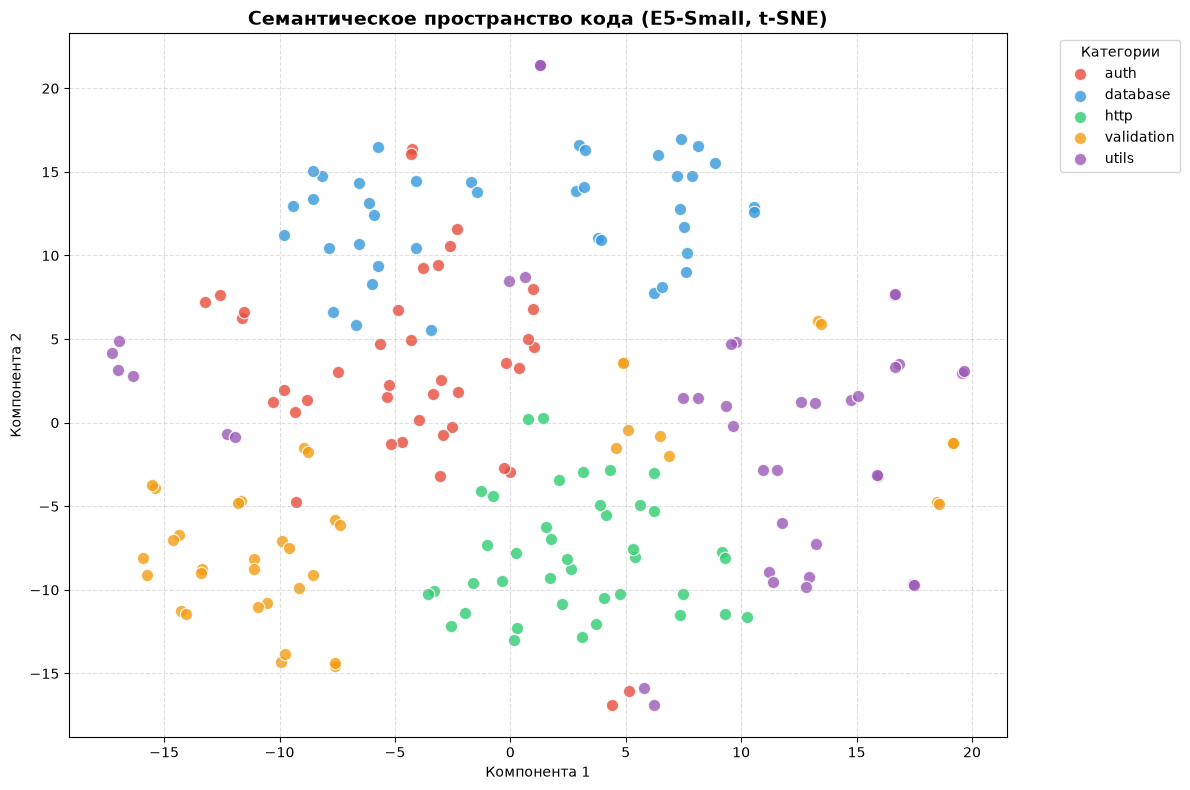

In [22]:
# 2. Визуализация t-SNE для лучшей модели

# ИСПРАВЛЕНИЕ: Достаем векторы корпуса (они уже в формате numpy)
best_embeddings = embeddings_cache[best_model_name]["corpus"]

# Строим t-SNE
coords = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(best_embeddings)

df_tsne = pd.DataFrame({
    "x": coords[:, 0],
    "y": coords[:, 1],
    "category": [item["category"] for item in corpus]
})

plt.figure(figsize=(12, 8))
for cat, color in category_colors.items():
    subset = df_tsne[df_tsne["category"] == cat]
    plt.scatter(subset["x"], subset["y"], c=color, label=cat, alpha=0.8, edgecolors='w', s=80)

plt.title(f"Семантическое пространство кода ({best_model_name}, t-SNE)", fontsize=14, fontweight='bold')
plt.xlabel("Компонента 1")
plt.ylabel("Компонента 2")
plt.legend(title="Категории", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [23]:
# 3. Анализ ошибок лучшей модели
print("\n=== Анализ ошибок ===")
errors = model_errors[best_model_name]
if not errors:
    print(f"Модель {best_model_name} отработала со 100% точностью.")
else:
    for e in errors:
        expected_cat = next(c["category"] for c in corpus if c["id"] == e["expected_id"])
        print(f"Запрос [{e['language']}]: '{e['query']}'")
        print(f"  Ожидалось: {e['expected_id']} (Категория: {expected_cat})")
        print(f"  Фактический Топ-3: {e['predicted_ids']}\n")


=== Анализ ошибок ===
Запрос [ru]: 'массовая вставка большого количества записей'
  Ожидалось: func_140 (Категория: database)
  Фактический Топ-3: ['func_182', 'func_127', 'func_082']



In [24]:
# 4. Сравнение качества при запросах на разных языках
print("=== Влияние языка запроса на поиск ===")
lang_stats = []
for lang in ["ru", "en"]:
    total = sum(1 for q in questions if q["language"] == lang)
    hits = sum(1 for r in search_results[best_model_name] if r["language"] == lang and r["is_hit"])
    lang_stats.append({"Язык": lang.upper(), "Всего запросов": total, "Успешных (Топ-3)": hits, "Precision@3": round(hits/total, 2)})

display(pd.DataFrame(lang_stats))

=== Влияние языка запроса на поиск ===


,Язык,Всего запросов,Успешных (Топ-3),Precision@3
0,RU,15,14,0.93
1,EN,10,10,1.00


## Шаг 4. Финальный вывод

**Какая модель выбрана и почему:**
На основе эмпирического тестирования на заданном корпусе данных лучшей признана модель `intfloat/multilingual-e5-small`. В сравнении с архитектурами семейства `paraphrase`, данная модель продемонстрировала максимальный показатель метрики Precision@3 и показала стабильность при кросс-языковом поиске. Архитектура E5 обучалась на задачах асимметричного поиска, что критически важно для нашей задачи: она математически корректно проецирует короткие абстрактные вопросы на естественном языке и длинные блоки структурированного программного кода в единое векторное пространство. 

**Ответ для защиты (Почему эта модель лучше?):**
«Мы выбрали Multilingual-E5, поскольку она обучена методами контрастивного обучения специально для задач асимметричного поиска (text-to-code). Благодаря использованию контекстных префиксов, она лучше классических моделей понимает разницу между абстрактным запросом пользователя и синтаксисом программного кода, что подтверждается наивысшей метрикой Precision@3 в нашем бенчмарке».